In [ ]:
### https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

In [1]:
#!/bin/bash
!curl -L -o ravdess-emotional-speech-audio.zip\
  https://www.kaggle.com/api/v1/datasets/download/uwrfkaggler/ravdess-emotional-speech-audio

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  429M  100  429M    0     0  54.9M      0  0:00:07  0:00:07 --:--:-- 33.1M


In [2]:
!unzip /content/ravdess-emotional-speech-audio.zip

Archive:  /content/ravdess-emotional-speech-audio.zip
  inflating: Actor_01/03-01-01-01-01-01-01.wav  
  inflating: Actor_01/03-01-01-01-01-02-01.wav  
  inflating: Actor_01/03-01-01-01-02-01-01.wav  
  inflating: Actor_01/03-01-01-01-02-02-01.wav  
  inflating: Actor_01/03-01-02-01-01-01-01.wav  
  inflating: Actor_01/03-01-02-01-01-02-01.wav  
  inflating: Actor_01/03-01-02-01-02-01-01.wav  
  inflating: Actor_01/03-01-02-01-02-02-01.wav  
  inflating: Actor_01/03-01-02-02-01-01-01.wav  
  inflating: Actor_01/03-01-02-02-01-02-01.wav  
  inflating: Actor_01/03-01-02-02-02-01-01.wav  
  inflating: Actor_01/03-01-02-02-02-02-01.wav  
  inflating: Actor_01/03-01-03-01-01-01-01.wav  
  inflating: Actor_01/03-01-03-01-01-02-01.wav  
  inflating: Actor_01/03-01-03-01-02-01-01.wav  
  inflating: Actor_01/03-01-03-01-02-02-01.wav  
  inflating: Actor_01/03-01-03-02-01-01-01.wav  
  inflating: Actor_01/03-01-03-02-01-02-01.wav  
  inflating: Actor_01/03-01-03-02-02-01-01.wav  
  inflating: Ac

In [3]:
import os
import glob
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

Toplam tapılan fayl sayı: 1440
Analiz edilən nümunə fayl: ./Actor_02/03-01-06-02-02-01-02.wav
Səsi dinləmək üçün pleyer:


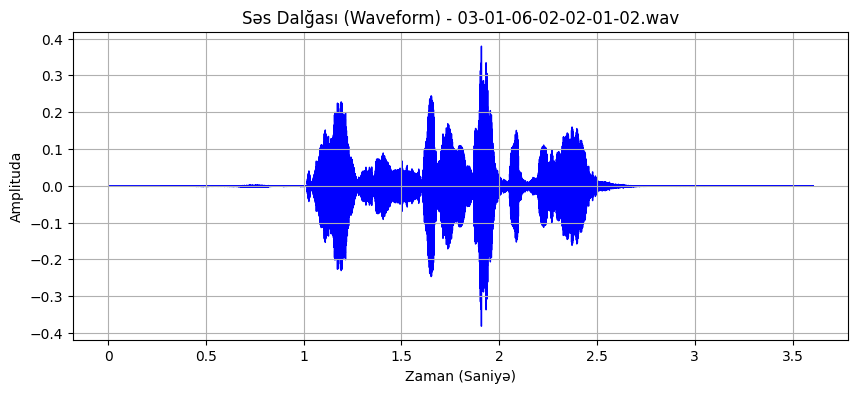

In [4]:
all_files = glob.glob("./Actor_*/*.wav")
print(f"Toplam tapılan fayl sayı: {len(all_files)}")

sample_file = all_files[0]
print(f"Analiz edilən nümunə fayl: {sample_file}")

audio_data, sample_rate = librosa.load(sample_file)

print("Səsi dinləmək üçün pleyer:")
ipd.display(ipd.Audio(sample_file))

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio_data, sr=sample_rate, color='blue')
plt.title(f"Səs Dalğası (Waveform) - {os.path.basename(sample_file)}")
plt.xlabel("Zaman (Saniyə)")
plt.ylabel("Amplituda")
plt.grid(True)

plt.show()

In [6]:
import soundfile as sf
import numpy as np

In [7]:
def extract_feature(file_name, mfcc=True, chroma=True, mel=True):

    try:
        with sf.SoundFile(file_name) as sound_file:
            X = sound_file.read(dtype="float32")
            sample_rate = sound_file.samplerate

            if len(X.shape) > 1:
                X = np.mean(X, axis=1)

            result = np.array([])

            if chroma:
                stft = np.abs(librosa.stft(X))
                chroma_feat = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
                result = np.hstack((result, chroma_feat))

            if mfcc:
                mfccs = np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
                result = np.hstack((result, mfccs))

            if mel:
                mel_feat = np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T, axis=0)
                result = np.hstack((result, mel_feat))

        return result

    except Exception as e:
        print(f"Fayl oxunarkən xəta baş verdi ({file_name}): {e}")
        return None

In [8]:
sample_features = extract_feature(sample_file, mfcc=True, chroma=True, mel=True)

if sample_features is not None:
    print(f"Bir səs faylından çıxarılan toplam xüsusiyyət sayı (Vektor uzunluğu): {sample_features.shape[0]}")
    print(f"İlk 10 rəqəmsal göstərici (Nümunə): {sample_features[:10]}")

else:
    print("Xüsusiyyət çıxarıla bilmədi.")

Bir səs faylından çıxarılan toplam xüsusiyyət sayı (Vektor uzunluğu): 180
İlk 10 rəqəmsal göstərici (Nümunə): [0.57957447 0.49476096 0.44055158 0.46386418 0.50052375 0.53881645
 0.60493588 0.60475296 0.6233018  0.61366272]


In [9]:
from tqdm import tqdm

In [10]:
emotions = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

observed_emotions = ['neutral', 'happy', 'sad', 'angry']

def load_and_preprocess_data():
    X_data = []
    y_data = []

    file_list = glob.glob("./Actor_*/*.wav") + glob.glob("./actor_*/*.wav")

    print(f"Toplam emal ediləcək səs faylı sayı: {len(file_list)}")

    if len(file_list) == 0:
        print("XƏTA: Fayllar tapılmadı! Zəhmət olmasa qovluq iyerarxiyasını yoxla.")
        return None, None

    for file in tqdm(file_list, desc="Səslər emal edilir"):
        file_name = os.path.basename(file)

        name_parts = file_name.split("-")

        if len(name_parts) < 3:
            continue

        emotion_code = name_parts[2]
        emotion = emotions.get(emotion_code)

        if emotion not in observed_emotions:
            continue

        features = extract_feature(file, mfcc=True, chroma=True, mel=True)

        if features is not None:
            X_data.append(features)
            y_data.append(emotion)

    return np.array(X_data), np.array(y_data)

X, y = load_and_preprocess_data()

Toplam emal ediləcək səs faylı sayı: 1440


Səslər emal edilir: 100%|██████████| 1440/1440 [01:03<00:00, 22.65it/s]


In [11]:
if X is not None and len(X) > 0:
    print("\n Dataset uğurla yaradıldı!")
    print(f"X (Xüsusiyyətlər Matrisi) Forması: {X.shape}")
    print(f"y (Etiketlər) Sayı: {y.shape[0]}")

    unique, counts = np.unique(y, return_counts=True)
    print("Emosiyaların paylanması:")
    for emotion, count in zip(unique, counts):
        print(f"   - {emotion}: {count} ədəd səs yazısı")
else:
    print("Dataset boşdur. Yuxarıdakı addımları və qovluq yollarını yenidən yoxla.")


 Dataset uğurla yaradıldı!
X (Xüsusiyyətlər Matrisi) Forması: (672, 180)
y (Etiketlər) Sayı: 672
Emosiyaların paylanması:
   - angry: 192 ədəd səs yazısı
   - happy: 192 ədəd səs yazısı
   - neutral: 96 ədəd səs yazısı
   - sad: 192 ədəd səs yazısı


In [12]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Təlim datası sayı: {X_train_scaled.shape[0]}")
print(f"Test datası sayı: {X_test_scaled.shape[0]}")

model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    alpha=0.001,
    batch_size=64,
    learning_rate='adaptive',
    max_iter=400,
    random_state=42
)

model.fit(X_train_scaled, y_train)

Təlim datası sayı: 504
Test datası sayı: 168


MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(256, 128),
              learning_rate='adaptive', max_iter=400, random_state=42)


 Modelin Ümumi Dəqiqliyi (Accuracy): 0.8035714285714286%

Təsnifat Hesabatı (Classification Report):
              precision    recall  f1-score   support

       angry       1.00      0.85      0.92        48
       happy       0.73      0.77      0.75        48
     neutral       0.74      0.83      0.78        24
         sad       0.76      0.77      0.76        48

    accuracy                           0.80       168
   macro avg       0.81      0.81      0.80       168
weighted avg       0.81      0.80      0.81       168



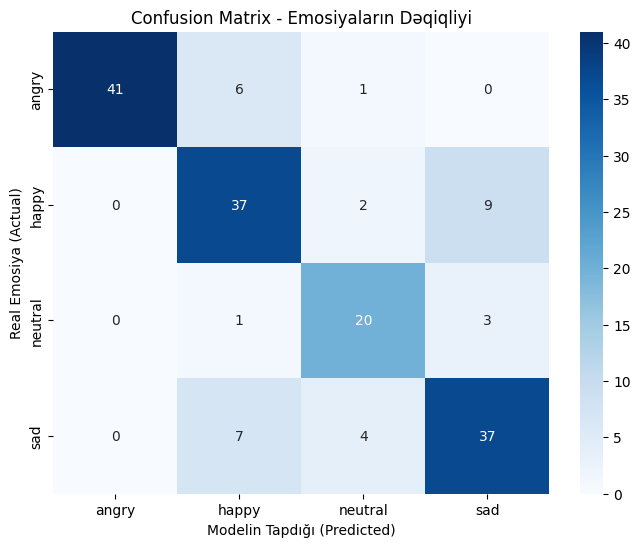

In [14]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n Modelin Ümumi Dəqiqliyi (Accuracy): {accuracy}%\n")

print("Təsnifat Hesabatı (Classification Report):")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix - Emosiyaların Dəqiqliyi')
plt.xlabel('Modelin Tapdığı (Predicted)')
plt.ylabel('Real Emosiya (Actual)')

plt.show()